# ✧ Dataset Bridge Scout: TILES / Sleep Efficiency / Stress

Goal:

Find whether we can solve the missing bridge:

sleep efficiency → stress / mood / memory / reaction

The first target is TILES-2018, because it may contain wearable sleep data plus stress/anxiety survey data.

This notebook will:

1. Try to access/download public dataset resources automatically.
2. Detect if a dataset is blocked by login.
3. Download public code/data resources when available.
4. Scan downloaded/local files for useful variables:
   - sleep efficiency
   - sleep quality
   - stress
   - anxiety
   - mood
   - reaction
   - memory
   - attention

We only use a dataset if the raw files actually contain bridge variables and output variables.

In [1]:
# ------------------------------------------------------------
# Dataset bridge scout: TILES / sleep efficiency / stress
# ------------------------------------------------------------

from pathlib import Path
import subprocess
import sys
import zipfile
import json
import re
import warnings

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Install packages if needed
# ------------------------------------------------------------

def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name

    try:
        __import__(import_name)
    except ImportError:
        print(f"{package_name} missing. Installing...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            package_name
        ])


install_if_missing("requests")
install_if_missing("pandas")
install_if_missing("openpyxl")

import requests
import pandas as pd

from IPython.display import display


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
GRAPH_DIR = PROJECT_DIR / "Graphs"

SCOUT_DIR = DATA_DIR / "dataset_scout"
DOWNLOAD_DIR = SCOUT_DIR / "downloads"
EXTRACT_DIR = SCOUT_DIR / "extracted"
MANUAL_DOWNLOAD_DIR = SCOUT_DIR / "manual_downloads"

for folder in [DATA_DIR, GRAPH_DIR, SCOUT_DIR, DOWNLOAD_DIR, EXTRACT_DIR, MANUAL_DOWNLOAD_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folder:")
print(PROJECT_DIR)

print("\nScout folder:")
print(SCOUT_DIR)

print("\nIf a dataset requires login, put the downloaded ZIP here and rerun this notebook:")
print(MANUAL_DOWNLOAD_DIR)


# ------------------------------------------------------------
# Helper: download a URL if possible
# ------------------------------------------------------------

def download_url(url, output_path):
    headers = {
        "User-Agent": "Mozilla/5.0 dataset-scout"
    }

    try:
        response = requests.get(
            url,
            headers=headers,
            timeout=60,
            allow_redirects=True
        )

        content_type = response.headers.get("content-type", "")
        output_path.write_bytes(response.content)

        return {
            "url": url,
            "output_path": str(output_path),
            "status_code": response.status_code,
            "content_type": content_type,
            "size_bytes": len(response.content),
            "success": response.status_code == 200
        }

    except Exception as error:
        return {
            "url": url,
            "output_path": str(output_path),
            "status_code": None,
            "content_type": "",
            "size_bytes": 0,
            "success": False,
            "error": str(error)
        }


# ------------------------------------------------------------
# 1. Check official TILES download page
# ------------------------------------------------------------

tiles_download_page = "https://tiles-data.isi.edu/download"

tiles_page_path = DOWNLOAD_DIR / "tiles_download_page.html"
tiles_page_result = download_url(tiles_download_page, tiles_page_path)

print("\nTILES download page check:")
print(tiles_page_result)

tiles_html = ""

if tiles_page_path.exists():
    tiles_html = tiles_page_path.read_text(encoding="utf-8", errors="ignore").lower()

if "must be logged in" in tiles_html or "sign in" in tiles_html:
    print("\nTILES status:")
    print("The official TILES download page is reachable, but it requires login.")
    print("The code cannot legally bypass that login.")
    print("If you can log in and download the ZIP manually, place it here:")
    print(MANUAL_DOWNLOAD_DIR)
else:
    print("\nTILES status:")
    print("No obvious login warning found on the downloaded page.")
    print("We still need to inspect whether there are real data files available.")


# ------------------------------------------------------------
# 2. Download public Pixleep GitHub repository
# ------------------------------------------------------------

# This repository is not the dataset itself, but it is useful because it shows
# expected ETRI/Pixleep folder and label structure.

pixleep_zip_url = "https://github.com/seongjiko/Pixleep/archive/refs/heads/master.zip"
pixleep_zip_path = DOWNLOAD_DIR / "pixleep_github_repository.zip"

pixleep_result = download_url(pixleep_zip_url, pixleep_zip_path)

print("\nPixleep GitHub repository download:")
print(pixleep_result)

if pixleep_zip_path.exists() and pixleep_zip_path.stat().st_size > 1000:
    try:
        pixleep_extract_path = EXTRACT_DIR / "pixleep_github_repository"

        if not pixleep_extract_path.exists():
            pixleep_extract_path.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(pixleep_zip_path, "r") as zip_ref:
            zip_ref.extractall(pixleep_extract_path)

        print("\nExtracted Pixleep GitHub repository to:")
        print(pixleep_extract_path)

    except Exception as error:
        print("\nCould not extract Pixleep ZIP:")
        print(error)


# ------------------------------------------------------------
# 3. Extract any manually downloaded ZIP files
# ------------------------------------------------------------

manual_zips = list(MANUAL_DOWNLOAD_DIR.glob("*.zip"))

if len(manual_zips) == 0:
    print("\nNo manual ZIP files found yet.")
else:
    print("\nManual ZIP files found:")
    for zip_path in manual_zips:
        print(zip_path)

        extract_target = EXTRACT_DIR / zip_path.stem
        extract_target.mkdir(parents=True, exist_ok=True)

        try:
            with zipfile.ZipFile(zip_path, "r") as zip_ref:
                zip_ref.extractall(extract_target)

            print(f"Extracted to: {extract_target}")

        except Exception as error:
            print(f"Could not extract {zip_path.name}: {error}")


# ------------------------------------------------------------
# 4. Scan local files for useful bridge/output variables
# ------------------------------------------------------------

sleep_keywords = [
    "sleep",
    "sleep_quality",
    "sleep quality",
    "quality",
    "psqi",
    "efficiency",
    "sleep_efficiency",
    "tst",
    "total_sleep",
    "total sleep",
    "waso",
    "sol",
    "latency"
]

output_keywords = [
    "stress",
    "anxiety",
    "mood",
    "affect",
    "emotion",
    "fatigue",
    "reaction",
    "pvt",
    "memory",
    "nback",
    "n-back",
    "stroop",
    "attention",
    "cognition",
    "cognitive"
]

input_keywords = [
    "screen",
    "phone",
    "smartphone",
    "usage",
    "use",
    "alcohol",
    "caffeine",
    "coffee",
    "exercise",
    "activity",
    "steps",
    "sedentary"
]


def find_keyword_matches(text, keywords):
    text_lower = str(text).lower()

    matches = []

    for keyword in keywords:
        if keyword.lower() in text_lower:
            matches.append(keyword)

    return sorted(set(matches))


def read_columns_safely(file_path):
    suffix = file_path.suffix.lower()

    try:
        if suffix == ".csv":
            df_head = pd.read_csv(file_path, nrows=5)
            return list(df_head.columns), "csv"

        if suffix == ".tsv":
            df_head = pd.read_csv(file_path, sep="\t", nrows=5)
            return list(df_head.columns), "tsv"

        if suffix in [".xlsx", ".xls"]:
            df_head = pd.read_excel(file_path, nrows=5)
            return list(df_head.columns), "excel"

        if suffix == ".json":
            text = file_path.read_text(encoding="utf-8", errors="ignore")[:5000]
            possible_keys = re.findall(r'"([^"]+)"\s*:', text)
            return sorted(set(possible_keys))[:80], "json"

    except Exception as error:
        return [f"READ_ERROR: {error}"], suffix.replace(".", "")

    return [], suffix.replace(".", "")


def scan_zip_contents(file_path):
    try:
        with zipfile.ZipFile(file_path, "r") as zip_ref:
            names = zip_ref.namelist()

        return names[:500]

    except Exception as error:
        return [f"ZIP_READ_ERROR: {error}"]


scan_roots = [
    DATA_DIR,
    SCOUT_DIR
]

allowed_extensions = [
    ".csv",
    ".tsv",
    ".xlsx",
    ".xls",
    ".json",
    ".zip"
]

inventory_rows = []

seen_paths = set()

for root in scan_roots:
    for file_path in root.rglob("*"):
        if not file_path.is_file():
            continue

        if str(file_path) in seen_paths:
            continue

        seen_paths.add(str(file_path))

        suffix = file_path.suffix.lower()

        if suffix not in allowed_extensions:
            continue

        relative_path = file_path.relative_to(PROJECT_DIR)

        if suffix == ".zip":
            zip_names = scan_zip_contents(file_path)
            searchable_text = " ".join(zip_names)

            sleep_matches = find_keyword_matches(searchable_text, sleep_keywords)
            output_matches = find_keyword_matches(searchable_text, output_keywords)
            input_matches = find_keyword_matches(searchable_text, input_keywords)

            inventory_rows.append({
                "file": str(relative_path),
                "file_type": "zip",
                "size_mb": round(file_path.stat().st_size / (1024 * 1024), 2),
                "column_or_filename_preview": " | ".join(zip_names[:20]),
                "sleep_matches": ", ".join(sleep_matches),
                "output_matches": ", ".join(output_matches),
                "input_matches": ", ".join(input_matches),
                "possible_use": (
                    "candidate bridge dataset"
                    if len(sleep_matches) > 0 and len(output_matches) > 0
                    else "inspect only"
                )
            })

        else:
            columns, file_type = read_columns_safely(file_path)
            searchable_text = " ".join(columns) + " " + file_path.name

            sleep_matches = find_keyword_matches(searchable_text, sleep_keywords)
            output_matches = find_keyword_matches(searchable_text, output_keywords)
            input_matches = find_keyword_matches(searchable_text, input_keywords)

            inventory_rows.append({
                "file": str(relative_path),
                "file_type": file_type,
                "size_mb": round(file_path.stat().st_size / (1024 * 1024), 2),
                "column_or_filename_preview": " | ".join([str(column) for column in columns[:30]]),
                "sleep_matches": ", ".join(sleep_matches),
                "output_matches": ", ".join(output_matches),
                "input_matches": ", ".join(input_matches),
                "possible_use": (
                    "candidate bridge dataset"
                    if len(sleep_matches) > 0 and len(output_matches) > 0
                    else "inspect only"
                )
            })


inventory_table = pd.DataFrame(inventory_rows)

if len(inventory_table) == 0:
    print("\nNo scannable files found.")
else:
    inventory_path = SCOUT_DIR / "dataset_bridge_scout_inventory.csv"
    inventory_table.to_csv(inventory_path, index=False)

    print("\nSaved full inventory to:")
    print(inventory_path)

    print("\nMost relevant candidate files:")
    candidate_table = inventory_table[
        inventory_table["possible_use"] == "candidate bridge dataset"
    ].copy()

    if len(candidate_table) == 0:
        print("No strong candidate files found yet.")
        print("This probably means the TILES dataset itself was not downloaded because of login.")
    else:
        display(candidate_table)

    print("\nAll scanned files:")
    display(inventory_table)


# ------------------------------------------------------------
# 5. Plain-English next-step summary
# ------------------------------------------------------------

print("\nNEXT STEP SUMMARY")

if "must be logged in" in tiles_html or "sign in" in tiles_html:
    print("\n1. TILES probably requires manual login/download.")
    print("2. If you can download it, put the ZIP file into:")
    print(MANUAL_DOWNLOAD_DIR)
    print("3. Then rerun this notebook.")
else:
    print("\n1. TILES page did not clearly block access.")
    print("2. Check the inventory table for downloaded data files.")

print("\nWhat we are looking for:")
print("- A file with sleep efficiency / sleep quality columns")
print("- AND stress / anxiety / mood / reaction / memory columns")
print("- Ideally in the same participant/day records")

Project folder:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis

Scout folder:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout

If a dataset requires login, put the downloaded ZIP here and rerun this notebook:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\manual_downloads

TILES download page check:
{'url': 'https://tiles-data.isi.edu/download', 'output_path': 'D:\\Documentos\\Sleep datasets\\sleep_installation_data_analysis\\data\\dataset_scout\\downloads\\tiles_download_page.html', 'status_code': 200, 'content_type': 'text/html; charset=utf-8', 'size_bytes': 4953, 'success': True}

TILES status:
The official TILES download page is reachable, but it requires login.
The code cannot legally bypass that login.
If you can log in and download the ZIP manually, place it here:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\manual_downloads

Pixleep GitHub repository download:
{

,file,file_type,size_mb,column_or_filename_preview,sleep_matches,output_matches,input_matches,possible_use
0,data\dataset_rds.zip,zip,219.79,dataset_rds/EMA/ | dataset_rds/EMA/Activity.Rd...,"psqi, sleep","mood, stress","activity, exercise, phone, usage",candidate bridge dataset
1681,data\external_sleep_datasets\bangladesh_sleep_...,csv,0.73,Your Age | What is your weight | Your Height |...,sleep,affect,use,candidate bridge dataset



All scanned files:


,file,file_type,size_mb,column_or_filename_preview,sleep_matches,output_matches,input_matches,possible_use
0,data\dataset_rds.zip,zip,219.79,dataset_rds/EMA/ | dataset_rds/EMA/Activity.Rd...,"psqi, sleep","mood, stress","activity, exercise, phone, usage",candidate bridge dataset
1,data\dataset_scout\dataset_bridge_scout_invent...,csv,0.26,file | file_type | size_mb | column_or_filenam...,sleep,,use,inspect only
2,data\dataset_scout\expanded_dataset_download_a...,csv,0.03,paper_name | possible_bridge | url | success |...,,,,inspect only
3,data\dataset_scout\expanded_dataset_links.csv,csv,0.26,paper_name | possible_bridge | parent_url | fo...,,,,inspect only
4,data\dataset_scout\expanded_download_file_scan...,csv,0.25,file | file_type | size_mb | column_preview | ...,sleep,,use,inspect only
...,...,...,...,...,...,...,...,...
1677,data\dataset_scout\link_downloads_extracted\Se...,csv,0.17,1581614221.000000 | IBI,,,,inspect only
1678,data\dataset_scout\link_downloads_extracted\Se...,csv,0.00,1581618517.26,,,,inspect only
1679,data\dataset_scout\link_downloads_extracted\Se...,csv,2.04,1581614221.000000,,,,inspect only
1680,data\external_sleep_datasets\bangladesh_sleep_...,zip,0.06,"Survey Dataset on Sleep Patterns, Health Effec...",sleep,,,inspect only



NEXT STEP SUMMARY

1. TILES probably requires manual login/download.
2. If you can download it, put the ZIP file into:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\manual_downloads
3. Then rerun this notebook.

What we are looking for:
- A file with sleep efficiency / sleep quality columns
- AND stress / anxiety / mood / reaction / memory columns
- Ideally in the same participant/day records


## 2. Online Dataset Link Hunt

The first TILES download attempt showed that the official TILES download page probably requires login.

This step searches inside the source files of promising dataset papers to find direct dataset links.

Candidate targets:

1. TILES-2018 Sleep Benchmark
   Possible bridge: sleep efficiency → stress/anxiety

2. Oura + N-back working memory dataset
   Possible bridge: sleep quality / sleep stages → memory

3. BiHeartS dataset
   Possible bridge: sleep efficiency / sleep quality → stress/fatigue

4. ETRI lifelog / Pixleep related resources
   Possible bridge: screen/phone behaviour → sleep quality/stress

The code will automatically download anything that is publicly accessible.
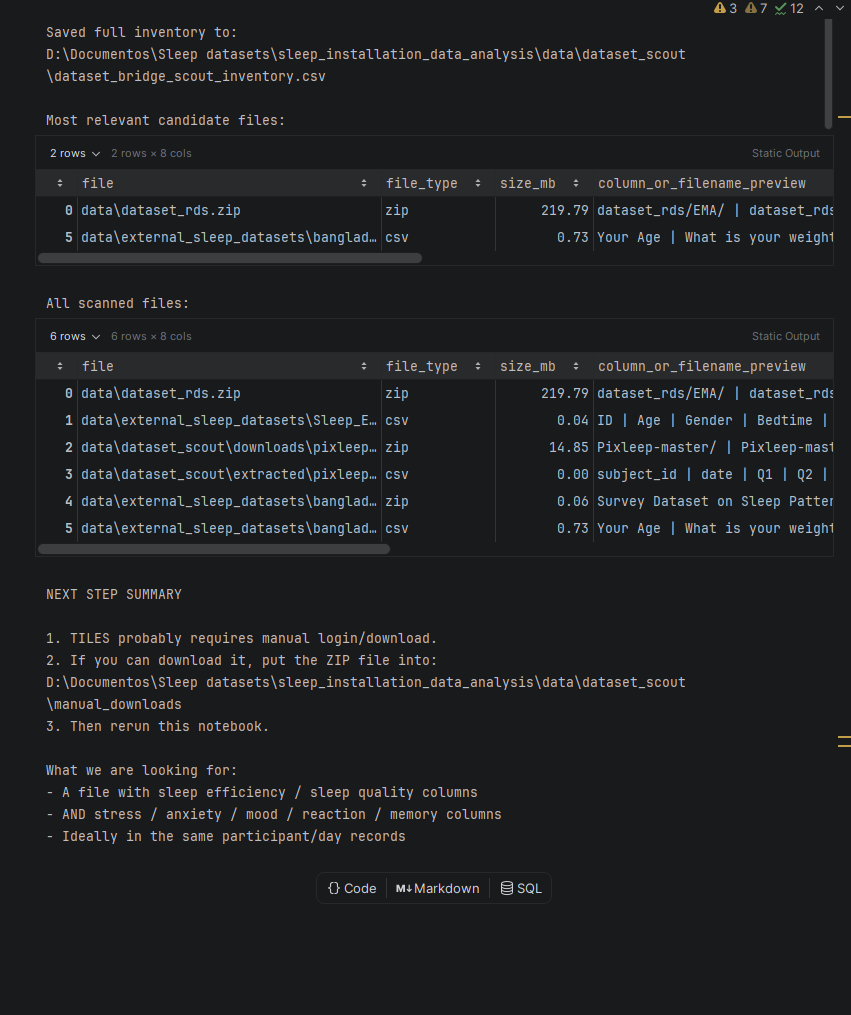
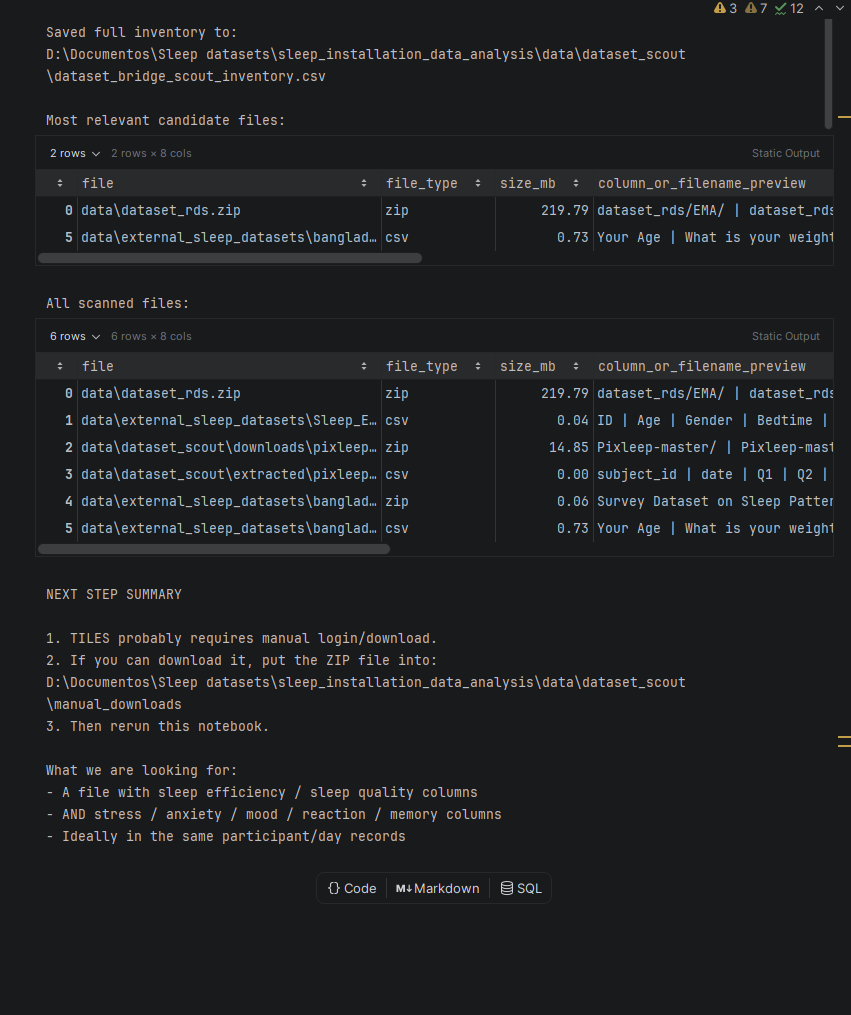

In [2]:
# ------------------------------------------------------------
# Online dataset link hunt through arXiv source files
# ------------------------------------------------------------

from pathlib import Path
import subprocess
import sys
import tarfile
import zipfile
import gzip
import shutil
import re
import warnings

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Install packages if needed
# ------------------------------------------------------------

def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name

    try:
        __import__(import_name)
    except ImportError:
        print(f"{package_name} missing. Installing...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            package_name
        ])


install_if_missing("requests")
install_if_missing("pandas")

import requests
import pandas as pd

from IPython.display import display


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
SCOUT_DIR = DATA_DIR / "dataset_scout"

ARXIV_DIR = SCOUT_DIR / "arxiv_sources"
LINK_DOWNLOAD_DIR = SCOUT_DIR / "link_downloads"

ARXIV_DIR.mkdir(parents=True, exist_ok=True)
LINK_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:")
print(PROJECT_DIR)

print("\nArXiv source folder:")
print(ARXIV_DIR)

print("\nPublic link download folder:")
print(LINK_DOWNLOAD_DIR)


# ------------------------------------------------------------
# Candidate dataset papers
# ------------------------------------------------------------

candidate_papers = [
    {
        "name": "TILES-2018 Sleep Benchmark",
        "arxiv_id": "2507.03520",
        "possible_bridge": "sleep efficiency / sleep quality → stress / anxiety"
    },
    {
        "name": "Oura + N-back working memory dataset",
        "arxiv_id": "2507.19491",
        "possible_bridge": "sleep quality / sleep stages → working memory"
    },
    {
        "name": "BiHeartS sleep dataset",
        "arxiv_id": "2308.06811",
        "possible_bridge": "sleep efficiency / sleep quality → stress / fatigue"
    },
    {
        "name": "ADARP stress and alcohol relapse dataset",
        "arxiv_id": "2206.14568",
        "possible_bridge": "alcohol / stress physiology, possible stress output"
    },
    {
        "name": "ETRI / lifelog sleep-quality resources",
        "arxiv_id": "2508.03698",
        "possible_bridge": "phone/lifelog behaviour → sleep quality / stress"
    }
]


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def safe_filename(text):
    text = text.replace("/", "_").replace("\\", "_")
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text)
    return text[:120]


def download_file(url, output_path, timeout=60):
    headers = {
        "User-Agent": "Mozilla/5.0 dataset-link-hunt"
    }

    try:
        response = requests.get(
            url,
            headers=headers,
            timeout=timeout,
            allow_redirects=True
        )

        output_path.write_bytes(response.content)

        return {
            "success": response.status_code == 200,
            "status_code": response.status_code,
            "content_type": response.headers.get("content-type", ""),
            "size_bytes": len(response.content),
            "final_url": response.url,
            "error": ""
        }

    except Exception as error:
        return {
            "success": False,
            "status_code": None,
            "content_type": "",
            "size_bytes": 0,
            "final_url": "",
            "error": str(error)
        }


def extract_arxiv_source(source_path, extract_path):
    extract_path.mkdir(parents=True, exist_ok=True)

    # Try tar
    try:
        if tarfile.is_tarfile(source_path):
            with tarfile.open(source_path, "r:*") as tar:
                tar.extractall(extract_path)
            return "tar"
    except Exception:
        pass

    # Try zip
    try:
        if zipfile.is_zipfile(source_path):
            with zipfile.ZipFile(source_path, "r") as zip_ref:
                zip_ref.extractall(extract_path)
            return "zip"
    except Exception:
        pass

    # Try gzip single file
    try:
        gz_target = extract_path / (source_path.stem + ".tex")
        with gzip.open(source_path, "rb") as source_file:
            gz_target.write_bytes(source_file.read())
        return "gzip"
    except Exception:
        pass

    # Fallback: copy as text
    try:
        fallback_target = extract_path / "source_text.txt"
        fallback_target.write_bytes(source_path.read_bytes())
        return "raw"
    except Exception:
        return "failed"


def read_all_text(folder):
    text_parts = []

    text_extensions = [
        ".tex",
        ".bib",
        ".bbl",
        ".txt",
        ".md",
        ".html",
        ".sty",
        ".cls"
    ]

    for file_path in folder.rglob("*"):
        if not file_path.is_file():
            continue

        if file_path.suffix.lower() not in text_extensions:
            continue

        try:
            text = file_path.read_text(encoding="utf-8", errors="ignore")
            text_parts.append(f"\n\n--- FILE: {file_path.name} ---\n{text}")
        except Exception:
            pass

    return "\n".join(text_parts)


def find_urls(text):
    # Basic URL extraction, then clean common TeX punctuation
    raw_urls = re.findall(r"https?://[^\s\}\]\)>'\"]+", text)

    cleaned_urls = []

    for url in raw_urls:
        url = url.strip()
        url = url.rstrip(".,;:")
        url = url.replace("\\_", "_")
        url = url.replace("\\", "")

        if url not in cleaned_urls:
            cleaned_urls.append(url)

    return cleaned_urls


def score_url(url):
    url_lower = url.lower()

    data_hosts = [
        "zenodo",
        "osf",
        "figshare",
        "github",
        "gitlab",
        "physionet",
        "openneuro",
        "huggingface",
        "kaggle",
        "dataverse",
        "dropbox",
        "drive.google",
        "doi.org",
        "data.mendeley"
    ]

    data_extensions = [
        ".zip",
        ".csv",
        ".tsv",
        ".xlsx",
        ".xls",
        ".json",
        ".rds",
        ".tar",
        ".gz"
    ]

    score = 0

    if any(host in url_lower for host in data_hosts):
        score += 2

    if any(extension in url_lower for extension in data_extensions):
        score += 2

    if "dataset" in url_lower or "data" in url_lower:
        score += 1

    return score


def looks_downloadable(url):
    url_lower = url.lower()

    downloadable_extensions = [
        ".zip",
        ".csv",
        ".tsv",
        ".xlsx",
        ".xls",
        ".json",
        ".rds",
        ".tar",
        ".gz"
    ]

    return any(extension in url_lower for extension in downloadable_extensions)


# ------------------------------------------------------------
# Download and inspect arXiv sources
# ------------------------------------------------------------

all_url_rows = []

for paper in candidate_papers:
    paper_name = paper["name"]
    arxiv_id = paper["arxiv_id"]

    print("\n" + "=" * 70)
    print(paper_name)
    print("arXiv:", arxiv_id)
    print("Possible bridge:", paper["possible_bridge"])

    source_url = f"https://arxiv.org/e-print/{arxiv_id}"

    source_path = ARXIV_DIR / f"{safe_filename(paper_name)}_{arxiv_id}.source"
    extract_path = ARXIV_DIR / f"{safe_filename(paper_name)}_{arxiv_id}_extracted"

    download_result = download_file(source_url, source_path)

    print("Download result:")
    print(download_result)

    if not download_result["success"]:
        print("Could not download source.")
        continue

    extract_type = extract_arxiv_source(source_path, extract_path)

    print("Extract type:")
    print(extract_type)

    all_text = read_all_text(extract_path)

    urls = find_urls(all_text)

    print("URLs found:", len(urls))

    for url in urls:
        all_url_rows.append({
            "paper_name": paper_name,
            "arxiv_id": arxiv_id,
            "possible_bridge": paper["possible_bridge"],
            "url": url,
            "url_score": score_url(url),
            "looks_downloadable": looks_downloadable(url)
        })


url_table = pd.DataFrame(all_url_rows)

if len(url_table) == 0:
    print("\nNo URLs found in arXiv source files.")
else:
    url_table = url_table.sort_values(
        by=["url_score", "paper_name"],
        ascending=[False, True]
    ).reset_index(drop=True)

    url_table_path = SCOUT_DIR / "online_dataset_url_hunt_results.csv"
    url_table.to_csv(url_table_path, index=False)

    print("\nSaved URL hunt results to:")
    print(url_table_path)

    print("\nMost promising dataset/data links:")
    display(url_table[url_table["url_score"] >= 2])

    print("\nAll discovered URLs:")
    display(url_table)


# ------------------------------------------------------------
# Try to download direct data-like links automatically
# ------------------------------------------------------------

download_attempt_rows = []

if len(url_table) > 0:
    direct_links = url_table[
        (url_table["url_score"] >= 2)
        & (url_table["looks_downloadable"] == True)
    ].copy()

    print("\nDirect downloadable-looking links found:")
    display(direct_links)

    for _, row in direct_links.iterrows():
        url = row["url"]

        file_name = safe_filename(
            row["paper_name"] + "_" + Path(url.split("?")[0]).name
        )

        if "." not in file_name:
            file_name += ".download"

        output_path = LINK_DOWNLOAD_DIR / file_name

        print("\nTrying to download:")
        print(url)

        result = download_file(url, output_path, timeout=90)

        print(result)

        download_attempt_rows.append({
            "paper_name": row["paper_name"],
            "possible_bridge": row["possible_bridge"],
            "url": url,
            "output_path": str(output_path),
            "success": result["success"],
            "status_code": result["status_code"],
            "content_type": result["content_type"],
            "size_mb": round(result["size_bytes"] / (1024 * 1024), 3),
            "final_url": result["final_url"],
            "error": result["error"]
        })

download_attempt_table = pd.DataFrame(download_attempt_rows)

if len(download_attempt_table) > 0:
    download_attempt_path = SCOUT_DIR / "online_dataset_download_attempts.csv"
    download_attempt_table.to_csv(download_attempt_path, index=False)

    print("\nSaved download attempts to:")
    print(download_attempt_path)

    print("\nDownload attempts:")
    display(download_attempt_table)
else:
    print("\nNo direct downloadable-looking data links were found.")


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nNEXT STEP SUMMARY")

if len(url_table) > 0:
    high_score_links = url_table[url_table["url_score"] >= 2]

    if len(high_score_links) > 0:
        print("Found potentially useful dataset/code/data links.")
        print("Send me the 'Most promising dataset/data links' table.")
    else:
        print("URLs were found, but none looked like direct dataset links.")
        print("Send me the full URL table if you want me to inspect it.")
else:
    print("No useful links found in arXiv sources.")

if len(download_attempt_table) > 0:
    successful = download_attempt_table[download_attempt_table["success"] == True]

    if len(successful) > 0:
        print("\nSome files downloaded successfully.")
        print("Next we should scan those downloaded files for sleep/output variables.")
    else:
        print("\nDownload attempts were made, but none clearly succeeded.")

Project folder:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis

ArXiv source folder:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\arxiv_sources

Public link download folder:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads

TILES-2018 Sleep Benchmark
arXiv: 2507.03520
Possible bridge: sleep efficiency / sleep quality → stress / anxiety
Download result:
{'success': True, 'status_code': 200, 'content_type': 'application/gzip', 'size_bytes': 2361632, 'final_url': 'https://arxiv.org/e-print/2507.03520', 'error': ''}
Extract type:
tar
URLs found: 9

Oura + N-back working memory dataset
arXiv: 2507.19491
Possible bridge: sleep quality / sleep stages → working memory
Download result:
{'success': True, 'status_code': 200, 'content_type': 'application/gzip', 'size_bytes': 6408445, 'final_url': 'https://arxiv.org/e-print/2507.19491', 'error': ''}
Extract type:
tar
URLs found: 84

BiHeartS sleep data

,paper_name,arxiv_id,possible_bridge,url,url_score,looks_downloadable
0,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress o...",https://github.com/rameshKrSah/ADARP_Dataset,3,False
1,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress o...",https://doi.org/10.2105/AJPH.47.5.624,2,False
2,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress o...",https://doi.org/10.1146/annurev.pu.05.050184.0...,2,False
3,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress o...",https://zenodo.org/record/6640290,2,False
4,BiHeartS sleep dataset,2308.06811,sleep efficiency / sleep quality → stress / fa...,https://github.com/brenhinkeller/preprint-temp...,2,False
...,...,...,...,...,...,...
72,Oura + N-back working memory dataset,2507.19491,sleep quality / sleep stages → working memory,https://doi.org/10.1371/journal.pone.0231906,2,False
73,Oura + N-back working memory dataset,2507.19491,sleep quality / sleep stages → working memory,https://doi.org/10.1080/00273170802285941,2,False
74,Oura + N-back working memory dataset,2507.19491,sleep quality / sleep stages → working memory,https://doi.org/10.3390/brainsci7070086,2,False
75,Oura + N-back working memory dataset,2507.19491,sleep quality / sleep stages → working memory,https://doi.org/10.12775/JEHS.2024.65.005,2,False



All discovered URLs:


,paper_name,arxiv_id,possible_bridge,url,url_score,looks_downloadable
0,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress o...",https://github.com/rameshKrSah/ADARP_Dataset,3,False
1,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress o...",https://doi.org/10.2105/AJPH.47.5.624,2,False
2,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress o...",https://doi.org/10.1146/annurev.pu.05.050184.0...,2,False
3,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress o...",https://zenodo.org/record/6640290,2,False
4,BiHeartS sleep dataset,2308.06811,sleep efficiency / sleep quality → stress / fa...,https://github.com/brenhinkeller/preprint-temp...,2,False
...,...,...,...,...,...,...
125,TILES-2018 Sleep Benchmark,2507.03520,sleep efficiency / sleep quality → stress / an...,http://www.ctan.org/tex-archive/macros/latex/c...,0,False
126,TILES-2018 Sleep Benchmark,2507.03520,sleep efficiency / sleep quality → stress / an...,http://spot.colorado.edu/~dixonj/,0,False
127,TILES-2018 Sleep Benchmark,2507.03520,sleep efficiency / sleep quality → stress / an...,http://www.ieee.org/publications_standards/pub...,0,False
128,TILES-2018 Sleep Benchmark,2507.03520,sleep efficiency / sleep quality → stress / an...,http://ctan.org/pkg/pifont,0,False



Direct downloadable-looking links found:


,paper_name,arxiv_id,possible_bridge,url,url_score,looks_downloadable



No direct downloadable-looking data links were found.

NEXT STEP SUMMARY
Found potentially useful dataset/code/data links.
Send me the 'Most promising dataset/data links' table.


## 3. Expand Dataset Links and Download Public Files

The previous step found promising dataset/data links, but no direct downloadable files yet.

This step opens those promising links, searches inside their pages for data files, and automatically downloads any public files it can access.

The target is still:

sleep efficiency / sleep quality → stress / mood / memory / reaction

In [3]:
# ------------------------------------------------------------
# Expand promising dataset links and download public data files
# ------------------------------------------------------------

from pathlib import Path
from urllib.parse import urljoin, urlparse
import subprocess
import sys
import re
import zipfile
import tarfile
import gzip
import shutil
import warnings

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Install packages if needed
# ------------------------------------------------------------

def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name

    try:
        __import__(import_name)
    except ImportError:
        print(f"{package_name} missing. Installing...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            package_name
        ])


install_if_missing("requests")
install_if_missing("pandas")
install_if_missing("openpyxl")

import requests
import pandas as pd

from IPython.display import display


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
SCOUT_DIR = DATA_DIR / "dataset_scout"

URL_RESULTS_PATH = SCOUT_DIR / "online_dataset_url_hunt_results.csv"

LINK_EXPANSION_DIR = SCOUT_DIR / "expanded_links"
LINK_DOWNLOAD_DIR = SCOUT_DIR / "link_downloads"
LINK_EXTRACT_DIR = SCOUT_DIR / "link_downloads_extracted"

for folder in [LINK_EXPANSION_DIR, LINK_DOWNLOAD_DIR, LINK_EXTRACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folder:")
print(PROJECT_DIR)

print("\nURL results file:")
print(URL_RESULTS_PATH)

print("\nDownload folder:")
print(LINK_DOWNLOAD_DIR)


# ------------------------------------------------------------
# Load previous URL hunt results
# ------------------------------------------------------------

if not URL_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "Could not find online_dataset_url_hunt_results.csv. "
        "Please run the previous URL-hunt cell first."
    )

url_table = pd.read_csv(URL_RESULTS_PATH)

pd.set_option("display.max_colwidth", 160)

print("\nLoaded URL table:")
display(url_table.head(20))

# Keep promising rows, plus key papers even if score is not perfect
important_paper_keywords = [
    "TILES",
    "Oura",
    "N-back",
    "BiHeartS",
    "ETRI"
]

is_important_paper = url_table["paper_name"].astype(str).apply(
    lambda text: any(keyword.lower() in text.lower() for keyword in important_paper_keywords)
)

promising_url_table = url_table[
    (url_table["url_score"] >= 2) | is_important_paper
].copy()

promising_url_table = promising_url_table.drop_duplicates(
    subset=["paper_name", "url"]
).reset_index(drop=True)

print("\nPromising links to inspect:")
display(promising_url_table[[
    "paper_name",
    "possible_bridge",
    "url",
    "url_score",
    "looks_downloadable"
]])


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def safe_filename(text):
    text = str(text)
    text = text.replace("/", "_").replace("\\", "_")
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text)
    return text[:140]


def request_url(url, timeout=60):
    headers = {
        "User-Agent": "Mozilla/5.0 dataset-link-expander"
    }

    try:
        response = requests.get(
            url,
            headers=headers,
            timeout=timeout,
            allow_redirects=True
        )

        return response, ""

    except Exception as error:
        return None, str(error)


def extract_links_from_html(html_text, base_url):
    hrefs = re.findall(
        r'href=["\']([^"\']+)["\']',
        html_text,
        flags=re.IGNORECASE
    )

    links = []

    for href in hrefs:
        href = href.strip()

        if href.startswith("#"):
            continue

        if href.startswith("mailto:"):
            continue

        if href.startswith("javascript:"):
            continue

        absolute_url = urljoin(base_url, href)

        if absolute_url not in links:
            links.append(absolute_url)

    return links


def score_url(url):
    url_lower = str(url).lower()

    data_hosts = [
        "zenodo",
        "osf",
        "figshare",
        "github",
        "gitlab",
        "physionet",
        "openneuro",
        "huggingface",
        "kaggle",
        "dataverse",
        "dropbox",
        "drive.google",
        "doi.org",
        "data.mendeley",
        "datadryad",
        "dryad"
    ]

    data_extensions = [
        ".zip",
        ".csv",
        ".tsv",
        ".xlsx",
        ".xls",
        ".json",
        ".rds",
        ".tar",
        ".gz",
        ".parquet"
    ]

    score = 0

    if any(host in url_lower for host in data_hosts):
        score += 2

    if any(extension in url_lower for extension in data_extensions):
        score += 2

    if "dataset" in url_lower or "data" in url_lower:
        score += 1

    if "download" in url_lower:
        score += 1

    return score


def looks_downloadable(url):
    url_lower = str(url).lower()

    downloadable_patterns = [
        ".zip",
        ".csv",
        ".tsv",
        ".xlsx",
        ".xls",
        ".json",
        ".rds",
        ".tar",
        ".gz",
        ".parquet",
        "download"
    ]

    return any(pattern in url_lower for pattern in downloadable_patterns)


def get_filename_from_response(url, response, fallback_prefix="download"):
    content_disposition = response.headers.get("content-disposition", "")

    match = re.search(
        r'filename="?([^"]+)"?',
        content_disposition
    )

    if match:
        return safe_filename(match.group(1))

    parsed_name = Path(urlparse(response.url).path).name

    if parsed_name:
        return safe_filename(parsed_name)

    return safe_filename(f"{fallback_prefix}.download")


def is_probably_html(response):
    content_type = response.headers.get("content-type", "").lower()

    if "text/html" in content_type:
        return True

    content_start = response.content[:200].lower()

    if b"<html" in content_start or b"<!doctype html" in content_start:
        return True

    return False


def add_unique_link(rows, seen, source_paper, possible_bridge, parent_url, found_url, source_type):
    if found_url in seen:
        return

    seen.add(found_url)

    rows.append({
        "paper_name": source_paper,
        "possible_bridge": possible_bridge,
        "parent_url": parent_url,
        "found_url": found_url,
        "source_type": source_type,
        "url_score": score_url(found_url),
        "looks_downloadable": looks_downloadable(found_url)
    })


# ------------------------------------------------------------
# Zenodo helper
# ------------------------------------------------------------

def get_zenodo_file_links(url):
    links = []

    record_match = re.search(
        r"zenodo\.org/(?:record|records)/(\d+)",
        url
    )

    if not record_match:
        return links

    record_id = record_match.group(1)
    api_url = f"https://zenodo.org/api/records/{record_id}"

    response, error = request_url(api_url)

    if response is None:
        return links

    if response.status_code != 200:
        return links

    try:
        record_json = response.json()
    except Exception:
        return links

    for file_info in record_json.get("files", []):
        file_links = file_info.get("links", {})
        file_url = file_links.get("self")

        if file_url:
            links.append(file_url)

    return links


# ------------------------------------------------------------
# GitHub helper
# ------------------------------------------------------------

def get_github_zip_links(url):
    links = []

    parsed = urlparse(url)

    if "github.com" not in parsed.netloc.lower():
        return links

    parts = [part for part in parsed.path.split("/") if part]

    if len(parts) < 2:
        return links

    owner = parts[0]
    repo = parts[1]

    if repo.endswith(".git"):
        repo = repo[:-4]

    links.append(f"https://github.com/{owner}/{repo}/archive/refs/heads/main.zip")
    links.append(f"https://github.com/{owner}/{repo}/archive/refs/heads/master.zip")

    return links


# ------------------------------------------------------------
# Expand links from promising pages
# ------------------------------------------------------------

expanded_rows = []
seen_expanded_links = set()

# Keep the scan reasonable
max_links_to_open = min(len(promising_url_table), 80)

for _, row in promising_url_table.head(max_links_to_open).iterrows():
    paper_name = row["paper_name"]
    possible_bridge = row["possible_bridge"]
    url = row["url"]

    print("\n" + "=" * 80)
    print("Inspecting:")
    print(paper_name)
    print(url)

    add_unique_link(
        rows=expanded_rows,
        seen=seen_expanded_links,
        source_paper=paper_name,
        possible_bridge=possible_bridge,
        parent_url="original",
        found_url=url,
        source_type="original"
    )

    # Zenodo API expansion
    for file_url in get_zenodo_file_links(url):
        add_unique_link(
            rows=expanded_rows,
            seen=seen_expanded_links,
            source_paper=paper_name,
            possible_bridge=possible_bridge,
            parent_url=url,
            found_url=file_url,
            source_type="zenodo_file"
        )

    # GitHub repository ZIP expansion
    for github_zip_url in get_github_zip_links(url):
        add_unique_link(
            rows=expanded_rows,
            seen=seen_expanded_links,
            source_paper=paper_name,
            possible_bridge=possible_bridge,
            parent_url=url,
            found_url=github_zip_url,
            source_type="github_zip_guess"
        )

    # Generic page expansion
    response, error = request_url(url, timeout=45)

    if response is None:
        print("Could not open page:")
        print(error)
        continue

    print("Status:", response.status_code)
    print("Content type:", response.headers.get("content-type", ""))

    if response.status_code != 200:
        continue

    if is_probably_html(response):
        html_text = response.text
        found_links = extract_links_from_html(html_text, response.url)

        useful_found_links = [
            found_url for found_url in found_links
            if score_url(found_url) >= 2 or looks_downloadable(found_url)
        ]

        print("Useful links found on page:", len(useful_found_links))

        for found_url in useful_found_links:
            add_unique_link(
                rows=expanded_rows,
                seen=seen_expanded_links,
                source_paper=paper_name,
                possible_bridge=possible_bridge,
                parent_url=url,
                found_url=found_url,
                source_type="page_link"
            )


expanded_link_table = pd.DataFrame(expanded_rows)

expanded_link_path = SCOUT_DIR / "expanded_dataset_links.csv"
expanded_link_table.to_csv(expanded_link_path, index=False)

print("\nSaved expanded links to:")
print(expanded_link_path)

print("\nMost promising expanded links:")
display(
    expanded_link_table.sort_values(
        by=["url_score", "looks_downloadable"],
        ascending=[False, False]
    ).head(80)
)


# ------------------------------------------------------------
# Download public data-like links
# ------------------------------------------------------------

download_candidates = expanded_link_table[
    (expanded_link_table["looks_downloadable"] == True)
    | (expanded_link_table["source_type"].isin(["zenodo_file", "github_zip_guess"]))
].copy()

download_candidates = download_candidates.drop_duplicates(
    subset=["found_url"]
).reset_index(drop=True)

print("\nDownload candidates:")
display(download_candidates[[
    "paper_name",
    "possible_bridge",
    "found_url",
    "source_type",
    "url_score"
]])

download_rows = []

for _, row in download_candidates.iterrows():
    url = row["found_url"]

    print("\n" + "-" * 80)
    print("Trying download:")
    print(url)

    response, error = request_url(url, timeout=120)

    if response is None:
        print("Failed:", error)

        download_rows.append({
            "paper_name": row["paper_name"],
            "possible_bridge": row["possible_bridge"],
            "url": url,
            "success": False,
            "status_code": None,
            "content_type": "",
            "size_mb": 0,
            "saved_path": "",
            "note": error
        })

        continue

    content_type = response.headers.get("content-type", "")

    print("Status:", response.status_code)
    print("Content type:", content_type)
    print("Size MB:", round(len(response.content) / (1024 * 1024), 3))

    if response.status_code != 200:
        note = f"HTTP status {response.status_code}"
        success = False
        saved_path = ""

    elif is_probably_html(response):
        note = "Looks like HTML page, not raw data file"
        success = False
        saved_path = ""

    else:
        filename = get_filename_from_response(
            url=url,
            response=response,
            fallback_prefix=safe_filename(row["paper_name"])
        )

        if "." not in filename:
            filename = filename + ".download"

        output_path = LINK_DOWNLOAD_DIR / filename
        output_path.write_bytes(response.content)

        note = "Downloaded"
        success = True
        saved_path = str(output_path)

        print("Saved to:")
        print(output_path)

    download_rows.append({
        "paper_name": row["paper_name"],
        "possible_bridge": row["possible_bridge"],
        "url": url,
        "success": success,
        "status_code": response.status_code,
        "content_type": content_type,
        "size_mb": round(len(response.content) / (1024 * 1024), 3),
        "saved_path": saved_path,
        "note": note
    })


download_table = pd.DataFrame(download_rows)

download_table_path = SCOUT_DIR / "expanded_dataset_download_attempts.csv"
download_table.to_csv(download_table_path, index=False)

print("\nSaved download attempts to:")
print(download_table_path)

print("\nDownload results:")
display(download_table)


# ------------------------------------------------------------
# Extract downloaded archives
# ------------------------------------------------------------

def extract_archive(file_path):
    file_path = Path(file_path)

    if not file_path.exists():
        return ""

    extract_target = LINK_EXTRACT_DIR / file_path.stem
    extract_target.mkdir(parents=True, exist_ok=True)

    try:
        if zipfile.is_zipfile(file_path):
            with zipfile.ZipFile(file_path, "r") as zip_ref:
                zip_ref.extractall(extract_target)
            return str(extract_target)

        if tarfile.is_tarfile(file_path):
            with tarfile.open(file_path, "r:*") as tar_ref:
                tar_ref.extractall(extract_target)
            return str(extract_target)

        if file_path.suffix.lower() == ".gz" and not file_path.name.endswith(".tar.gz"):
            output_file = extract_target / file_path.stem

            with gzip.open(file_path, "rb") as source_file:
                output_file.write_bytes(source_file.read())

            return str(extract_target)

    except Exception as error:
        return f"EXTRACT_ERROR: {error}"

    return ""


extract_rows = []

successful_downloads = download_table[
    download_table["success"] == True
].copy()

for _, row in successful_downloads.iterrows():
    saved_path = row["saved_path"]

    extract_path = extract_archive(saved_path)

    extract_rows.append({
        "paper_name": row["paper_name"],
        "saved_path": saved_path,
        "extract_path": extract_path
    })


extract_table = pd.DataFrame(extract_rows)

print("\nArchive extraction results:")
display(extract_table)


# ------------------------------------------------------------
# Scan downloaded/extracted files for useful variables
# ------------------------------------------------------------

sleep_keywords = [
    "sleep",
    "sleep_quality",
    "sleep quality",
    "quality",
    "psqi",
    "efficiency",
    "sleep_efficiency",
    "sleep efficiency",
    "tst",
    "total_sleep",
    "total sleep",
    "waso",
    "sol",
    "latency",
    "rem",
    "deep",
    "light"
]

output_keywords = [
    "stress",
    "anxiety",
    "mood",
    "affect",
    "emotion",
    "fatigue",
    "reaction",
    "pvt",
    "memory",
    "nback",
    "n-back",
    "stroop",
    "attention",
    "cognition",
    "cognitive"
]

input_keywords = [
    "screen",
    "phone",
    "smartphone",
    "usage",
    "use",
    "alcohol",
    "caffeine",
    "coffee",
    "exercise",
    "activity",
    "steps",
    "sedentary"
]


def find_keyword_matches(text, keywords):
    text_lower = str(text).lower()

    matches = []

    for keyword in keywords:
        if keyword.lower() in text_lower:
            matches.append(keyword)

    return sorted(set(matches))


def read_columns_safely(file_path):
    suffix = file_path.suffix.lower()

    try:
        if suffix == ".csv":
            df_head = pd.read_csv(file_path, nrows=5)
            return list(df_head.columns), "csv"

        if suffix == ".tsv":
            df_head = pd.read_csv(file_path, sep="\t", nrows=5)
            return list(df_head.columns), "tsv"

        if suffix in [".xlsx", ".xls"]:
            df_head = pd.read_excel(file_path, nrows=5)
            return list(df_head.columns), "excel"

        if suffix == ".json":
            text = file_path.read_text(encoding="utf-8", errors="ignore")[:10000]
            possible_keys = re.findall(r'"([^"]+)"\s*:', text)
            return sorted(set(possible_keys))[:120], "json"

        if suffix == ".parquet":
            df_head = pd.read_parquet(file_path)
            return list(df_head.columns), "parquet"

    except Exception as error:
        return [f"READ_ERROR: {error}"], suffix.replace(".", "")

    return [], suffix.replace(".", "")


scan_extensions = [
    ".csv",
    ".tsv",
    ".xlsx",
    ".xls",
    ".json",
    ".parquet"
]

scan_roots = [
    LINK_DOWNLOAD_DIR,
    LINK_EXTRACT_DIR
]

scan_rows = []

for root in scan_roots:
    for file_path in root.rglob("*"):
        if not file_path.is_file():
            continue

        suffix = file_path.suffix.lower()

        if suffix not in scan_extensions:
            continue

        columns, file_type = read_columns_safely(file_path)

        searchable_text = " ".join([str(column) for column in columns]) + " " + file_path.name

        sleep_matches = find_keyword_matches(searchable_text, sleep_keywords)
        output_matches = find_keyword_matches(searchable_text, output_keywords)
        input_matches = find_keyword_matches(searchable_text, input_keywords)

        scan_rows.append({
            "file": str(file_path.relative_to(PROJECT_DIR)),
            "file_type": file_type,
            "size_mb": round(file_path.stat().st_size / (1024 * 1024), 3),
            "column_preview": " | ".join([str(column) for column in columns[:40]]),
            "sleep_matches": ", ".join(sleep_matches),
            "output_matches": ", ".join(output_matches),
            "input_matches": ", ".join(input_matches),
            "possible_use": (
                "candidate bridge dataset"
                if len(sleep_matches) > 0 and len(output_matches) > 0
                else "inspect only"
            )
        })


scan_table = pd.DataFrame(scan_rows)

scan_table_path = SCOUT_DIR / "expanded_download_file_scan.csv"
scan_table.to_csv(scan_table_path, index=False)

print("\nSaved downloaded-file scan to:")
print(scan_table_path)

if len(scan_table) == 0:
    print("\nNo readable downloaded data files were found.")
else:
    print("\nCandidate bridge files from downloaded data:")
    candidate_scan_table = scan_table[
        scan_table["possible_use"] == "candidate bridge dataset"
    ].copy()

    if len(candidate_scan_table) == 0:
        print("No downloaded files clearly contain both sleep and output variables yet.")
    else:
        display(candidate_scan_table)

    print("\nAll readable downloaded files:")
    display(scan_table)


# ------------------------------------------------------------
# Plain-English summary
# ------------------------------------------------------------

print("\nNEXT STEP SUMMARY")

if len(successful_downloads) == 0:
    print("No raw data files were successfully downloaded from the expanded links.")
    print("This means the useful links are probably landing pages, papers, or protected repositories.")
    print("Send me the expanded link table so we can inspect which source is worth trying manually.")
else:
    print(f"Downloaded {len(successful_downloads)} public file(s).")

    if len(scan_table) > 0:
        candidate_count = len(scan_table[scan_table["possible_use"] == "candidate bridge dataset"])

        print(f"Readable downloaded files found: {len(scan_table)}")
        print(f"Candidate bridge files found: {candidate_count}")

        if candidate_count > 0:
            print("Send me the candidate bridge files table.")
        else:
            print("Send me the all readable downloaded files table.")

Project folder:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis

URL results file:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\online_dataset_url_hunt_results.csv

Download folder:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads

Loaded URL table:


,paper_name,arxiv_id,possible_bridge,url,url_score,looks_downloadable
0,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress output",https://github.com/rameshKrSah/ADARP_Dataset,3,False
1,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress output",https://doi.org/10.2105/AJPH.47.5.624,2,False
2,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress output",https://doi.org/10.1146/annurev.pu.05.050184.001535,2,False
3,ADARP stress and alcohol relapse dataset,2206.14568,"alcohol / stress physiology, possible stress output",https://zenodo.org/record/6640290,2,False
4,BiHeartS sleep dataset,2308.06811,sleep efficiency / sleep quality → stress / fatigue,https://github.com/brenhinkeller/preprint-template.tex,2,False
5,Oura + N-back working memory dataset,2507.19491,sleep quality / sleep stages → working memory,https://github.com/borisveytsman/acmart/issues/402,2,False
6,Oura + N-back working memory dataset,2507.19491,sleep quality / sleep stages → working memory,https://github.com/borisveytsman/acmart/issues/410,2,False
7,Oura + N-back working memory dataset,2507.19491,sleep quality / sleep stages → working memory,https://doi.org/#1,2,False
8,Oura + N-back working memory dataset,2507.19491,sleep quality / sleep stages → working memory,https://doi.org/10.48550/arXiv.2308.06811,2,False
9,Oura + N-back working memory dataset,2507.19491,sleep quality / sleep stages → working memory,https://doi.org/10.1007/978-3-642-04898-2_110,2,False



Promising links to inspect:


,paper_name,possible_bridge,url,url_score,looks_downloadable
0,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://github.com/rameshKrSah/ADARP_Dataset,3,False
1,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://doi.org/10.2105/AJPH.47.5.624,2,False
2,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://doi.org/10.1146/annurev.pu.05.050184.001535,2,False
3,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://zenodo.org/record/6640290,2,False
4,BiHeartS sleep dataset,sleep efficiency / sleep quality → stress / fatigue,https://github.com/brenhinkeller/preprint-template.tex,2,False
...,...,...,...,...,...
118,TILES-2018 Sleep Benchmark,sleep efficiency / sleep quality → stress / anxiety,http://www.ctan.org/tex-archive/macros/latex/contrib/supported/IEEEtran/testflow,0,False
119,TILES-2018 Sleep Benchmark,sleep efficiency / sleep quality → stress / anxiety,http://spot.colorado.edu/~dixonj/,0,False
120,TILES-2018 Sleep Benchmark,sleep efficiency / sleep quality → stress / anxiety,http://www.ieee.org/publications_standards/publications/rights/index.html,0,False
121,TILES-2018 Sleep Benchmark,sleep efficiency / sleep quality → stress / anxiety,http://ctan.org/pkg/pifont,0,False



Inspecting:
ADARP stress and alcohol relapse dataset
https://github.com/rameshKrSah/ADARP_Dataset
Status: 200
Content type: text/html; charset=utf-8
Useful links found on page: 144

Inspecting:
ADARP stress and alcohol relapse dataset
https://doi.org/10.2105/AJPH.47.5.624
Status: 403
Content type: text/html; charset=UTF-8

Inspecting:
ADARP stress and alcohol relapse dataset
https://doi.org/10.1146/annurev.pu.05.050184.001535
Status: 200
Content type: text/html;charset=UTF-8
Useful links found on page: 1

Inspecting:
ADARP stress and alcohol relapse dataset
https://zenodo.org/record/6640290
Status: 200
Content type: text/html; charset=utf-8
Useful links found on page: 55

Inspecting:
BiHeartS sleep dataset
https://github.com/brenhinkeller/preprint-template.tex
Status: 200
Content type: text/html; charset=utf-8
Useful links found on page: 139

Inspecting:
Oura + N-back working memory dataset
https://github.com/borisveytsman/acmart/issues/402
Status: 200
Content type: text/html; charset

...


Archive extraction results:


,paper_name,saved_path,extract_path
0,ADARP stress and alcohol relapse dataset,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\ADARP_Dataset-master.zip,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads_extracted\ADARP_Dataset-master
1,ADARP stress and alcohol relapse dataset,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\manifest.json,
2,ADARP stress and alcohol relapse dataset,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Final_Phone_Survey_Stress_Events.zip,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads_extracted\Final_Phone_Survey_Stress_Events
3,ADARP stress and alcohol relapse dataset,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Alcohol_Use_Data.zip,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads_extracted\Alcohol_Use_Data
4,ADARP stress and alcohol relapse dataset,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Sensor_Data.zip,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads_extracted\Sensor_Data
5,ADARP stress and alcohol relapse dataset,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Final_Phone_Survey_Stress_Events.zip,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads_extracted\Final_Phone_Survey_Stress_Events
6,ADARP stress and alcohol relapse dataset,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Alcohol_Use_Data.zip,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads_extracted\Alcohol_Use_Data
7,ADARP stress and alcohol relapse dataset,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Sensor_Data.zip,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads_extracted\Sensor_Data
8,ADARP stress and alcohol relapse dataset,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Alcohol_Use_Data.zip,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads_extracted\Alcohol_Use_Data
9,ADARP stress and alcohol relapse dataset,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Final_Phone_Survey_Stress_Events.zip,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads_extracted\Final_Phone_Survey_Stress_Events



Saved downloaded-file scan to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\expanded_download_file_scan.csv

Candidate bridge files from downloaded data:
No downloaded files clearly contain both sleep and output variables yet.

All readable downloaded files:


,file,file_type,size_mb,column_preview,sleep_matches,output_matches,input_matches,possible_use
0,data\dataset_scout\link_downloads\manifest.json,json,0.001,display | icons | id | name | platform | prefer_related_applications | related_applications | short_name | sizes | src | start_url | type | url,,,,inspect only
1,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\ACC.csv,csv,3.753,1556563573.000000 | 1556563573.000000 | 1556563573.000000.1,,,,inspect only
2,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\BVP.csv,csv,4.520,1556563573.00,,,,inspect only
3,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\EDA.csv,csv,0.391,1556563573.000000,,,,inspect only
4,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\HR.csv,csv,0.067,1556563583.000000,,,,inspect only
...,...,...,...,...,...,...,...,...
1655,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A02160_200213-171701\EDA.csv,csv,3.057,1581614221.000000,,,,inspect only
1656,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A02160_200213-171701\HR.csv,csv,0.557,1581614231.000000,,,,inspect only
1657,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A02160_200213-171701\IBI.csv,csv,0.175,1581614221.000000 | IBI,,,,inspect only
1658,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A02160_200213-171701\tags.csv,csv,0.000,1581618517.26,,,,inspect only



NEXT STEP SUMMARY
Downloaded 22 public file(s).
Readable downloaded files found: 1660
Candidate bridge files found: 0
Send me the all readable downloaded files table.


## 4. Folder-Level Bridge Scan

The previous scan found 1660 readable files, but no single file contained both sleep and output variables.

This does not mean the downloaded datasets are useless.

Many datasets store sleep variables and output variables in separate files.

This step groups files by downloaded dataset folder and checks whether each folder contains:

- at least one sleep-related file
- at least one output-related file

This helps us find datasets that may become usable after merging files.

In [4]:
# ------------------------------------------------------------
# Folder-level bridge scan
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd
import re

from IPython.display import display

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
SCOUT_DIR = DATA_DIR / "dataset_scout"

SCAN_PATH = SCOUT_DIR / "expanded_download_file_scan.csv"

if not SCAN_PATH.exists():
    raise FileNotFoundError(
        "Could not find expanded_download_file_scan.csv. "
        "Please run the expanded download scan first."
    )

scan_table = pd.read_csv(SCAN_PATH)

print("Loaded scan table:")
print(SCAN_PATH)
print("Rows:", len(scan_table))

pd.set_option("display.max_colwidth", 180)

display(scan_table.head())


# ------------------------------------------------------------
# Broader keyword lists
# ------------------------------------------------------------

sleep_keywords = [
    "sleep",
    "oura",
    "bedtime",
    "bed_time",
    "bed time",
    "wake",
    "awake",
    "latency",
    "efficiency",
    "rem",
    "deep",
    "light",
    "duration",
    "total_sleep",
    "total sleep",
    "tst",
    "waso",
    "psqi",
    "readiness",
    "hrv",
    "heart_rate",
    "heart rate",
    "resting"
]

output_keywords = [
    "stress",
    "anxiety",
    "mood",
    "affect",
    "emotion",
    "fatigue",
    "tired",
    "sleepy",
    "reaction",
    "response_time",
    "response time",
    "rt",
    "pvt",
    "memory",
    "working memory",
    "nback",
    "n_back",
    "n-back",
    "stroop",
    "attention",
    "cognition",
    "cognitive",
    "accuracy",
    "correct",
    "score"
]

input_keywords = [
    "screen",
    "phone",
    "smartphone",
    "usage",
    "use",
    "unlock",
    "lock",
    "alcohol",
    "caffeine",
    "coffee",
    "exercise",
    "activity",
    "steps",
    "sedentary"
]


def keyword_matches(text, keywords):
    text = str(text).lower()
    matches = []

    for keyword in keywords:
        if keyword.lower() in text:
            matches.append(keyword)

    return sorted(set(matches))


def dataset_group_from_path(file_string):
    """
    Groups files by downloaded/extracted dataset folder.
    This is intentionally approximate but useful for scouting.
    """
    path = Path(str(file_string))
    parts = path.parts

    if "link_downloads_extracted" in parts:
        index = parts.index("link_downloads_extracted")
        if index + 1 < len(parts):
            return parts[index + 1]

    if "link_downloads" in parts:
        index = parts.index("link_downloads")
        if index + 1 < len(parts):
            return parts[index + 1]

    if "downloads" in parts:
        index = parts.index("downloads")
        if index + 1 < len(parts):
            return parts[index + 1]

    return parts[-1]


# ------------------------------------------------------------
# Score each file
# ------------------------------------------------------------

scored_rows = []

for _, row in scan_table.iterrows():
    file_path = str(row.get("file", ""))
    column_preview = str(row.get("column_preview", ""))

    searchable_text = file_path + " " + column_preview

    sleep_matches = keyword_matches(searchable_text, sleep_keywords)
    output_matches = keyword_matches(searchable_text, output_keywords)
    input_matches = keyword_matches(searchable_text, input_keywords)

    scored_rows.append({
        "dataset_group": dataset_group_from_path(file_path),
        "file": file_path,
        "file_type": row.get("file_type", ""),
        "size_mb": row.get("size_mb", ""),
        "column_preview": column_preview,
        "sleep_matches": ", ".join(sleep_matches),
        "output_matches": ", ".join(output_matches),
        "input_matches": ", ".join(input_matches),
        "sleep_score": len(sleep_matches),
        "output_score": len(output_matches),
        "input_score": len(input_matches),
        "total_score": len(sleep_matches) + len(output_matches) + len(input_matches)
    })

scored_file_table = pd.DataFrame(scored_rows)

scored_file_path = SCOUT_DIR / "folder_level_scored_files.csv"
scored_file_table.to_csv(scored_file_path, index=False)

print("\nSaved scored file table to:")
print(scored_file_path)


# ------------------------------------------------------------
# Display likely useful individual files
# ------------------------------------------------------------

likely_files = scored_file_table[
    (scored_file_table["sleep_score"] > 0)
    | (scored_file_table["output_score"] > 0)
    | (scored_file_table["input_score"] > 0)
].copy()

likely_files = likely_files.sort_values(
    by=["total_score", "sleep_score", "output_score"],
    ascending=False
)

print("\nLikely useful individual files:")
display(likely_files.head(80))


# ------------------------------------------------------------
# Group-level scan
# ------------------------------------------------------------

group_rows = []

for dataset_group, group_df in scored_file_table.groupby("dataset_group"):
    sleep_files = group_df[group_df["sleep_score"] > 0]
    output_files = group_df[group_df["output_score"] > 0]
    input_files = group_df[group_df["input_score"] > 0]

    sleep_match_text = ", ".join(
        sorted(set(", ".join(sleep_files["sleep_matches"]).split(", ")))
    ).strip(", ")

    output_match_text = ", ".join(
        sorted(set(", ".join(output_files["output_matches"]).split(", ")))
    ).strip(", ")

    input_match_text = ", ".join(
        sorted(set(", ".join(input_files["input_matches"]).split(", ")))
    ).strip(", ")

    top_sleep_files = " || ".join(
        sleep_files.sort_values("sleep_score", ascending=False)["file"].head(5).tolist()
    )

    top_output_files = " || ".join(
        output_files.sort_values("output_score", ascending=False)["file"].head(5).tolist()
    )

    top_input_files = " || ".join(
        input_files.sort_values("input_score", ascending=False)["file"].head(5).tolist()
    )

    possible_use = "no"

    if len(sleep_files) > 0 and len(output_files) > 0:
        possible_use = "yes: sleep + output files in same dataset folder"

    if len(sleep_files) > 0 and len(input_files) > 0 and len(output_files) > 0:
        possible_use = "strong: input + sleep + output files in same dataset folder"

    group_rows.append({
        "dataset_group": dataset_group,
        "total_files": len(group_df),
        "sleep_file_count": len(sleep_files),
        "output_file_count": len(output_files),
        "input_file_count": len(input_files),
        "sleep_matches": sleep_match_text,
        "output_matches": output_match_text,
        "input_matches": input_match_text,
        "possible_use": possible_use,
        "top_sleep_files": top_sleep_files,
        "top_output_files": top_output_files,
        "top_input_files": top_input_files
    })

group_bridge_table = pd.DataFrame(group_rows)

group_bridge_table = group_bridge_table.sort_values(
    by=["possible_use", "sleep_file_count", "output_file_count", "input_file_count"],
    ascending=False
)

group_bridge_path = SCOUT_DIR / "folder_level_bridge_candidates.csv"
group_bridge_table.to_csv(group_bridge_path, index=False)

print("\nSaved folder-level bridge candidates to:")
print(group_bridge_path)

print("\nFolder-level bridge candidates:")
candidate_groups = group_bridge_table[
    group_bridge_table["possible_use"] != "no"
].copy()

if len(candidate_groups) == 0:
    print("No folder-level candidates found.")
else:
    display(candidate_groups)


# ------------------------------------------------------------
# Print details for top candidate groups
# ------------------------------------------------------------

print("\nTop candidate group details:")

for _, group_row in candidate_groups.head(5).iterrows():
    dataset_group = group_row["dataset_group"]

    print("\n" + "=" * 90)
    print("Dataset group:")
    print(dataset_group)
    print("Possible use:")
    print(group_row["possible_use"])

    group_df = scored_file_table[
        scored_file_table["dataset_group"] == dataset_group
    ].copy()

    group_df = group_df.sort_values(
        by=["total_score", "sleep_score", "output_score"],
        ascending=False
    )

    display(group_df.head(30))


# ------------------------------------------------------------
# Special focus: Oura / N-back candidates
# ------------------------------------------------------------

oura_focus = scored_file_table[
    scored_file_table.apply(
        lambda row: (
            "oura" in str(row["file"]).lower()
            or "nback" in str(row["file"]).lower()
            or "n_back" in str(row["file"]).lower()
            or "n-back" in str(row["file"]).lower()
            or "working" in str(row["file"]).lower()
            or "memory" in str(row["file"]).lower()
            or "oura" in str(row["column_preview"]).lower()
            or "nback" in str(row["column_preview"]).lower()
            or "n_back" in str(row["column_preview"]).lower()
            or "n-back" in str(row["column_preview"]).lower()
            or "working" in str(row["column_preview"]).lower()
            or "memory" in str(row["column_preview"]).lower()
        ),
        axis=1
    )
].copy()

oura_focus = oura_focus.sort_values(
    by=["total_score", "sleep_score", "output_score"],
    ascending=False
)

print("\nOura / N-back / working-memory focused files:")
if len(oura_focus) == 0:
    print("No Oura/N-back focused files found.")
else:
    display(oura_focus.head(80))


# ------------------------------------------------------------
# Special focus: TILES / stress candidates
# ------------------------------------------------------------

tiles_focus = scored_file_table[
    scored_file_table.apply(
        lambda row: (
            "tiles" in str(row["file"]).lower()
            or "stress" in str(row["file"]).lower()
            or "anxiety" in str(row["file"]).lower()
            or "stress" in str(row["column_preview"]).lower()
            or "anxiety" in str(row["column_preview"]).lower()
        ),
        axis=1
    )
].copy()

tiles_focus = tiles_focus.sort_values(
    by=["total_score", "sleep_score", "output_score"],
    ascending=False
)

print("\nTILES / stress / anxiety focused files:")
if len(tiles_focus) == 0:
    print("No TILES/stress focused files found.")
else:
    display(tiles_focus.head(80))


print("\nNEXT STEP SUMMARY")

if len(candidate_groups) > 0:
    print("We found dataset folders that contain sleep-related files and output-related files.")
    print("Send me the Folder-level bridge candidates table and the Oura/N-back focused files table.")
else:
    print("No folder-level candidates found yet.")
    print("Send me the Likely useful individual files table.")

Loaded scan table:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\expanded_download_file_scan.csv
Rows: 1660


,file,file_type,size_mb,column_preview,sleep_matches,output_matches,input_matches,possible_use
0,data\dataset_scout\link_downloads\manifest.json,json,0.001,display | icons | id | name | platform | prefer_related_applications | related_applications | short_name | sizes | src | start_url | type | url,NaN,NaN,NaN,inspect only
1,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\ACC.csv,csv,3.753,1556563573.000000 | 1556563573.000000 | 1556563573.000000.1,NaN,NaN,NaN,inspect only
2,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\BVP.csv,csv,4.520,1556563573.00,NaN,NaN,NaN,inspect only
3,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\EDA.csv,csv,0.391,1556563573.000000,NaN,NaN,NaN,inspect only
4,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\HR.csv,csv,0.067,1556563583.000000,NaN,NaN,NaN,inspect only



Saved scored file table to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\folder_level_scored_files.csv

Likely useful individual files:


,dataset_group,file,file_type,size_mb,column_preview,sleep_matches,output_matches,input_matches,sleep_score,output_score,input_score,total_score
0,manifest.json,data\dataset_scout\link_downloads\manifest.json,json,0.001,display | icons | id | name | platform | prefer_related_applications | related_applications | short_name | sizes | src | start_url | type | url,,rt,,0,1,0,1
1,Sensor_Data,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\ACC.csv,csv,3.753,1556563573.000000 | 1556563573.000000 | 1556563573.000000.1,,rt,,0,1,0,1
2,Sensor_Data,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\BVP.csv,csv,4.520,1556563573.00,,rt,,0,1,0,1
3,Sensor_Data,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\EDA.csv,csv,0.391,1556563573.000000,,rt,,0,1,0,1
4,Sensor_Data,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190429-184613\HR.csv,csv,0.067,1556563583.000000,,rt,,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
75,Sensor_Data,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190507-181335\IBI.csv,csv,0.372,1557252815.000000 | IBI,,rt,,0,1,0,1
76,Sensor_Data,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190507-181335\tags.csv,csv,0.000,READ_ERROR: No columns to parse from file,,rt,,0,1,0,1
77,Sensor_Data,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190507-181335\TEMP.csv,csv,0.777,1557252815.000000,,rt,,0,1,0,1
78,Sensor_Data,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 101C\A01f4c_190508-174012\ACC.csv,csv,0.673,1557337212.000000 | 1557337212.000000 | 1557337212.000000.1,,rt,,0,1,0,1



Saved folder-level bridge candidates to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\folder_level_bridge_candidates.csv

Folder-level bridge candidates:
No folder-level candidates found.

Top candidate group details:

Oura / N-back / working-memory focused files:
No Oura/N-back focused files found.

TILES / stress / anxiety focused files:
No TILES/stress focused files found.

NEXT STEP SUMMARY
No folder-level candidates found yet.
Send me the Likely useful individual files table.


In [5]:
 # ------------------------------------------------------------
# Diagnostic: what did we actually download?
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

SCOUT_DIR = PROJECT_DIR / "data" / "dataset_scout"

download_attempts_path = SCOUT_DIR / "expanded_dataset_download_attempts.csv"
scan_path = SCOUT_DIR / "expanded_download_file_scan.csv"
scored_path = SCOUT_DIR / "folder_level_scored_files.csv"

pd.set_option("display.max_colwidth", 220)

print("Checking downloaded files...")

if download_attempts_path.exists():
    download_attempts = pd.read_csv(download_attempts_path)

    successful_downloads = download_attempts[
        download_attempts["success"] == True
    ].copy()

    print("\nSuccessful downloads:")
    display(successful_downloads[
        [
            "paper_name",
            "possible_bridge",
            "url",
            "size_mb",
            "saved_path",
            "note"
        ]
    ])
else:
    print("No expanded_dataset_download_attempts.csv found.")

if scan_path.exists():
    scan_table = pd.read_csv(scan_path)

    print("\nReadable file types:")
    display(
        scan_table["file_type"]
        .value_counts()
        .reset_index()
        .rename(columns={"index": "file_type", "file_type": "count"})
    )

    print("\nLargest readable files:")
    display(
        scan_table.sort_values("size_mb", ascending=False)
        .head(30)[
            [
                "file",
                "file_type",
                "size_mb",
                "column_preview",
                "sleep_matches",
                "output_matches",
                "input_matches"
            ]
        ]
    )

    print("\nFiles with sleep-related words:")
    sleep_files = scan_table[
        scan_table["sleep_matches"].fillna("").astype(str).str.len() > 0
    ].copy()

    if len(sleep_files) == 0:
        print("No sleep-related files found.")
    else:
        display(sleep_files.head(80)[
            [
                "file",
                "file_type",
                "size_mb",
                "column_preview",
                "sleep_matches",
                "output_matches",
                "input_matches"
            ]
        ])

    print("\nFiles with output-related words:")
    output_files = scan_table[
        scan_table["output_matches"].fillna("").astype(str).str.len() > 0
    ].copy()

    if len(output_files) == 0:
        print("No output-related files found.")
    else:
        display(output_files.head(80)[
            [
                "file",
                "file_type",
                "size_mb",
                "column_preview",
                "sleep_matches",
                "output_matches",
                "input_matches"
            ]
        ])

else:
    print("No expanded_download_file_scan.csv found.")

if scored_path.exists():
    scored_table = pd.read_csv(scored_path)

    print("\nDataset groups:")
    display(
        scored_table["dataset_group"]
        .value_counts()
        .reset_index()
        .rename(columns={"index": "dataset_group", "dataset_group": "file_count"})
        .head(50)
    )
else:
    print("No folder_level_scored_files.csv found.")

Checking downloaded files...

Successful downloads:


,paper_name,possible_bridge,url,size_mb,saved_path,note
1,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://github.com/rameshKrSah/ADARP_Dataset/archive/refs/heads/master.zip,0.021,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\ADARP_Dataset-master.zip,Downloaded
2,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://github.com/manifest.json,0.001,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\manifest.json,Downloaded
3,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://zenodo.org/api/records/6640290/files/Final%20Phone%20Survey%20Stress%20Events.zip/content,0.022,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Final_Phone_Survey_Stress_Events.zip,Downloaded
4,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://zenodo.org/api/records/6640290/files/Alcohol%20Use%20Data.zip/content,1.940,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Alcohol_Use_Data.zip,Downloaded
5,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://zenodo.org/api/records/6640290/files/Sensor%20Data.zip/content,1388.841,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Sensor_Data.zip,Downloaded
6,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://zenodo.org/records/6640290/files/Final%20Phone%20Survey%20Stress%20Events.zip,0.022,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Final_Phone_Survey_Stress_Events.zip,Downloaded
7,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://zenodo.org/records/6640290/files/Alcohol%20Use%20Data.zip,1.940,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Alcohol_Use_Data.zip,Downloaded
8,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://zenodo.org/records/6640290/files/Sensor%20Data.zip,1388.841,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Sensor_Data.zip,Downloaded
9,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://zenodo.org/records/6640290/files/Alcohol%20Use%20Data.zip?download=1,1.940,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Alcohol_Use_Data.zip,Downloaded
11,ADARP stress and alcohol relapse dataset,"alcohol / stress physiology, possible stress output",https://zenodo.org/records/6640290/files/Final%20Phone%20Survey%20Stress%20Events.zip?download=1,0.022,D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\dataset_scout\link_downloads\Final_Phone_Survey_Stress_Events.zip,Downloaded



Readable file types:


,count,count
0,csv,1659
1,json,1



Largest readable files:


,file,file_type,size_mb,column_preview,sleep_matches,output_matches,input_matches
1612,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A01d53_200214-180136\BVP.csv,csv,48.780,1581703296.00,NaN,NaN,NaN
1626,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A02160_200207-183104\BVP.csv,csv,48.689,1581100264.00,NaN,NaN,NaN
1598,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A01d53_200210-194142\BVP.csv,csv,47.031,1581363702.00,NaN,NaN,NaN
1619,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A01d53_200216-200731\BVP.csv,csv,45.352,1581883651.00,NaN,NaN,NaN
1276,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 110C\A01aa7_200208-144058\BVP.csv,csv,45.310,1581172858.00,NaN,NaN,NaN
1625,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A02160_200207-183104\ACC.csv,csv,39.410,1581100264.000000 | 1581100264.000000 | 1581100264.000000.1,NaN,NaN,NaN
1611,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A01d53_200214-180136\ACC.csv,csv,37.220,1581703296.000000 | 1581703296.000000 | 1581703296.000000.1,NaN,NaN,NaN
1618,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A01d53_200216-200731\ACC.csv,csv,34.967,1581883651.000000 | 1581883651.000000 | 1581883651.000000.1,NaN,NaN,NaN
1605,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 112C\A01d53_200212-155534\BVP.csv,csv,33.870,1581522934.00,NaN,NaN,NaN
1275,data\dataset_scout\link_downloads_extracted\Sensor_Data\Sensor Data\Part 110C\A01aa7_200208-144058\ACC.csv,csv,32.630,1581172858.000000 | 1581172858.000000 | 1581172858.000000.1,NaN,NaN,NaN



Files with sleep-related words:
No sleep-related files found.

Files with output-related words:
No output-related files found.

Dataset groups:


,file_count,count
0,Sensor_Data,1659
1,manifest.json,1


NameError: name 'input_bridge_comparison_table' is not defined